# ARIMA Forecasting per Produk

Notebook ini melakukan forecasting menggunakan model ARIMA untuk **setiap produk** secara individual.

## 1. Import Library

In [1]:
%pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load Dataset

In [2]:
# Load the dataset
file_path = 'Dataset_Forecasting_ARIMA_Lengkap1.xlsx'
dataset = pd.read_excel(file_path)

print("Dataset Info:")
print(dataset.head())
print(f"\nJumlah data: {len(dataset)}")
print(f"Kolom: {dataset.columns.tolist()}")

Dataset Info:
                  Date  AERIS10  BB 10  BB 30  BR45  BR75   CC   CNF  CNF 10  \
0  2025-01-01 00:00:00      0.0    0.0    0.0   0.0   0.0  0.0   0.0     0.0   
1  2025-01-02 00:00:00      0.0    0.0    1.0   0.0   0.0  0.0   3.0    14.0   
2  2025-01-03 00:00:00      0.0    1.0    0.0   0.0   0.0  0.0  18.0    45.0   
3  2025-01-04 00:00:00      0.0    0.0    0.0   0.0   0.0  0.0   8.0     4.0   
4  2025-01-05 00:00:00      0.0    0.0    0.0   0.0   0.0  0.0   0.0     0.0   

   CNF 100  ...  MYB  MYB 10  MYB 100   NB   TC  TC 10  TC 250  TEETH10   TP  \
0      0.0  ...  0.0     0.0      0.0  0.0  0.0    0.0     0.0      0.0  0.0   
1      0.0  ...  0.0     3.0      0.0  0.0  0.0    1.0     0.0      0.0  0.0   
2      0.0  ...  0.0     0.0      0.0  2.0  3.0    6.0     1.0      0.0  0.0   
3      0.0  ...  0.0     0.0      0.0  0.0  0.0    0.0     0.0      0.0  0.0   
4      0.0  ...  0.0     0.0      0.0  0.0  0.0    0.0     0.0      0.0  0.0   

   Total_Sales  
0      

## 3. Preprocessing Data

In [3]:
# Remove non-date rows (summary rows like 'pemakaian maksimum', 'pemakaian rata rata', 'lead time')
dataset = dataset[pd.to_datetime(dataset['Date'], errors='coerce').notna()].copy()

# Convert 'Date' column to datetime format and set as index
dataset['Date'] = pd.to_datetime(dataset['Date'])
dataset.set_index('Date', inplace=True)

# Identifikasi kolom produk (exclude Total_Sales)
product_columns = [col for col in dataset.columns if col != 'Total_Sales']

print(f"Jumlah produk yang akan diprediksi: {len(product_columns)}")
print(f"\nDaftar produk: {', '.join(product_columns)}")

Jumlah produk yang akan diprediksi: 37

Daftar produk: AERIS10, BB 10, BB 30, BR45, BR75, CC, CNF, CNF 10, CNF 100, CNF 250, DS, DS 10, DS 100, DS 250, EC45, EC75, GF, GF 10, GF 250, IB, IB 10, IB 100, JOY, JOY 10, JOY 100, LDR, LDR 10, LDR 250, MYB, MYB 10, MYB 100, NB, TC, TC 10, TC 250, TEETH10, TP


## 4. Fungsi Helper untuk ARIMA Forecasting

In [9]:
def arima_forecast_product(
    data,
    product_name,
    train_ratio=0.9,
    base_orders=None,
    extended_orders=None,
    use_extended=False,
    fill_method='ffill'
    ):
    """
    Melakukan ARIMA forecasting untuk satu produk dengan pemilihan order adaptif.
    
    Strategy:
    - Base tuning: kandidat order ringkas untuk semua produk
    - Extended tuning: kandidat order lebih luas untuk produk yang MAE-nya masih tinggi
    - Low-MAE products akan disederhanakan order-nya di tahap segment tuning
    """
    try:
        # Pastikan index date harian lengkap
        complete_date_range = pd.date_range(start=data.index.min(), end=data.index.max(), freq='D')
        data_reindexed = data.reindex(complete_date_range)
        
        # Isi missing value
        if fill_method == 'ffill':
            data_reindexed = data_reindexed.ffill().fillna(0)
        else:
            data_reindexed = data_reindexed.fillna(0)
        
        # ADF Test untuk stationarity
        adf_result = adfuller(data_reindexed)
        is_stationary = adf_result[1] < 0.05
        d_pref = 0 if is_stationary else 1
        
        # Kandidat order default
        default_base_orders = [
            (1, d_pref, 1),
            (2, d_pref, 1),
            (1, d_pref, 2),
            (2, d_pref, 2),
            (3, d_pref, 1),
            (1, 0, 1),
            (1, 1, 1),
            (0, 1, 1),
        ]
        
        default_extended_orders = default_base_orders + [
            (3, d_pref, 2),
            (2, d_pref, 3),
            (3, d_pref, 3),
            (4, d_pref, 1),
            (4, d_pref, 2),
            (2, 1, 3),
            (3, 1, 2),
            (3, 1, 3),
            (2, 0, 3),
            (3, 0, 2),
        ]
        
        # Hilangkan duplikasi order sambil pertahankan urutan
        def unique_orders(orders):
            seen = set()
            unique = []
            for order in orders:
                if order not in seen:
                    seen.add(order)
                    unique.append(order)
            return unique
        
        default_base_orders = unique_orders(default_base_orders)
        default_extended_orders = unique_orders(default_extended_orders)
        
        selected_base_orders = unique_orders(base_orders) if base_orders else default_base_orders
        selected_extended_orders = unique_orders(extended_orders) if extended_orders else default_extended_orders
        candidate_orders = selected_extended_orders if use_extended else selected_base_orders
        
        # Split data
        train_size = int(len(data_reindexed) * train_ratio)
        train_data = data_reindexed[:train_size]
        test_data = data_reindexed[train_size:]
        
        if len(train_data) < 10 or len(test_data) < 2:
            raise ValueError('Data train/test terlalu sedikit untuk ARIMA')
        
        # Evaluasi semua kandidat order
        order_metrics = []
        best_model = None
        best_order = None
        best_forecast = None
        best_mae = np.inf
        
        for order in candidate_orders:
            try:
                model = ARIMA(train_data, order=order)
                fitted_model = model.fit()
                forecast = fitted_model.forecast(steps=len(test_data))
                forecast = np.maximum(forecast, 0)
                
                mae = mean_absolute_error(test_data, forecast)
                rmse = np.sqrt(mean_squared_error(test_data, forecast))
                mape = np.mean(np.abs((test_data - forecast) / (test_data + 1))) * 100
                
                order_metrics.append({
                    'Order': order,
                    'MAE': float(mae),
                    'RMSE': float(rmse),
                    'MAPE (%)': float(mape),
                    'AIC': float(fitted_model.aic)
                })
                
                if mae < best_mae:
                    best_mae = mae
                    best_model = fitted_model
                    best_order = order
                    best_forecast = forecast
            except Exception:
                # Skip kandidat yang gagal fit
                continue
        
        if best_model is None:
            raise ValueError('Semua kandidat order ARIMA gagal di-fit')
        
        order_metrics_df = pd.DataFrame(order_metrics).sort_values('MAE').reset_index(drop=True)
        scope_label = 'extended' if use_extended else 'base'
        
        return {
            'product': product_name,
            'success': True,
            'train_data': train_data,
            'test_data': test_data,
            'forecast': best_forecast,
            'mae': float(best_mae),
            'rmse': float(np.sqrt(mean_squared_error(test_data, best_forecast))),
            'mape': float(np.mean(np.abs((test_data - best_forecast) / (test_data + 1))) * 100),
            'is_stationary': is_stationary,
            'adf_pvalue': float(adf_result[1]),
            'used_order': best_order,
            'order_metrics': order_metrics_df,
            'search_scope': scope_label,
            'model_summary': best_model.summary()
        }
    except Exception as e:
        print(f"Error forecasting {product_name}: {str(e)}")
        return {
            'product': product_name,
            'success': False,
            'error': str(e)
        }

print("✅ Fungsi helper ARIMA adaptif telah dibuat")

✅ Fungsi helper ARIMA adaptif telah dibuat


## 5. Jalankan ARIMA Forecasting untuk Semua Produk

In [10]:
# Dictionary untuk menyimpan hasil forecasting
forecast_results = {}

print("Memulai forecasting tahap 1 (base tuning) untuk semua produk...")
print("=" * 90)

for i, product in enumerate(product_columns, 1):
    print(f"[{i}/{len(product_columns)}] Base tuning: {product}...", end=" ")
    
    result = arima_forecast_product(
        data=dataset[product],
        product_name=product,
        train_ratio=0.9,
        use_extended=False
    )
    
    forecast_results[product] = result
    
    if result['success']:
        order_str = str(result.get('used_order'))
        print(f"✅ MAE: {result['mae']:.2f} | Order: {order_str}")
    else:
        print("❌ Error")

print("=" * 90)
print("Segmentasi MAE dan penyesuaian model (tahap 2)...")

# Ambil hasil sukses untuk menentukan segmentasi MAE
successful_items = {p: r for p, r in forecast_results.items() if r.get('success')}

if successful_items:
    mae_series = pd.Series({p: r['mae'] for p, r in successful_items.items()})
    q_low = mae_series.quantile(0.33)
    q_high = mae_series.quantile(0.66)
    
    print(f"Batas MAE rendah <= {q_low:.2f}")
    print(f"Batas MAE menengah <= {q_high:.2f}")
    
    retuned_count = 0
    simplified_count = 0
    
    for product, old_result in list(successful_items.items()):
        old_mae = old_result['mae']
        old_order = old_result['used_order']
        
        # 1) Produk MAE rendah: pilih model lebih sederhana bila performanya mirip (parsimonious)
        if old_mae <= q_low:
            metrics_df = old_result.get('order_metrics', pd.DataFrame())
            if not metrics_df.empty:
                tolerance = old_mae * 1.05  # toleransi 5% dari MAE terbaik
                near_best = metrics_df[metrics_df['MAE'] <= tolerance].copy()
                if not near_best.empty:
                    near_best['complexity'] = near_best['Order'].apply(lambda x: sum(x))
                    simple_choice = near_best.sort_values(['complexity', 'MAE']).iloc[0]['Order']
                    
                    if simple_choice != old_order:
                        simplified_result = arima_forecast_product(
                            data=dataset[product],
                            product_name=product,
                            train_ratio=0.9,
                            base_orders=[simple_choice],
                            use_extended=False
                        )
                        if simplified_result['success']:
                            forecast_results[product] = simplified_result
                            simplified_count += 1
                            print(
                                f"[LOW MAE] {product}: order {old_order} -> {simple_choice} "
                                f"| MAE {old_mae:.2f} -> {simplified_result['mae']:.2f}"
                            )
        
        # 2) Produk selain MAE rendah: lakukan extended tuning
        else:
            retuned_result = arima_forecast_product(
                data=dataset[product],
                product_name=product,
                train_ratio=0.9,
                use_extended=True
            )
            if retuned_result['success'] and retuned_result['mae'] < old_mae:
                forecast_results[product] = retuned_result
                retuned_count += 1
                print(
                    f"[RETUNE] {product}: order {old_order} -> {retuned_result['used_order']} "
                    f"| MAE {old_mae:.2f} -> {retuned_result['mae']:.2f}"
                )
    
    print("=" * 90)
    print(f"✅ Simplifikasi model (MAE rendah): {simplified_count} produk")
    print(f"✅ Retuning model (MAE menengah/tinggi): {retuned_count} produk")
else:
    print("Tidak ada hasil sukses untuk segmentasi MAE.")

print("=" * 90)
print(f"✅ Forecasting + penyesuaian model selesai untuk {len(product_columns)} produk!")

Memulai forecasting tahap 1 (base tuning) untuk semua produk...
[1/37] Base tuning: AERIS10... ✅ MAE: 0.01 | Order: (1, 0, 1)
[2/37] Base tuning: BB 10... ✅ MAE: 0.13 | Order: (1, 1, 1)
[3/37] Base tuning: BB 30... ✅ MAE: 0.04 | Order: (1, 1, 1)
[4/37] Base tuning: BR45... ✅ MAE: 0.00 | Order: (1, 1, 1)
[5/37] Base tuning: BR75... ✅ MAE: 0.00 | Order: (1, 0, 1)
[6/37] Base tuning: CC... ✅ MAE: 0.10 | Order: (1, 1, 1)
[7/37] Base tuning: CNF... ✅ MAE: 0.87 | Order: (0, 1, 1)
[8/37] Base tuning: CNF 10... ✅ MAE: 3.55 | Order: (1, 1, 1)
[9/37] Base tuning: CNF 100... ✅ MAE: 0.00 | Order: (1, 1, 1)
[10/37] Base tuning: CNF 250... ✅ MAE: 0.00 | Order: (0, 1, 1)
[11/37] Base tuning: DS... ✅ MAE: 0.13 | Order: (1, 1, 1)
[12/37] Base tuning: DS 10... ✅ MAE: 0.06 | Order: (0, 1, 1)
[13/37] Base tuning: DS 100... ✅ MAE: 0.00 | Order: (2, 1, 2)
[14/37] Base tuning: DS 250... ✅ MAE: 0.00 | Order: (1, 1, 1)
[15/37] Base tuning: EC45... ✅ MAE: 0.00 | Order: (1, 1, 1)
[16/37] Base tuning: EC75... ✅ M

## 6. Ringkasan Hasil Forecasting

In [11]:
# Buat dataframe ringkasan
summary_data = []

for product, result in forecast_results.items():
    if result['success']:
        summary_data.append({
            'Produk': product,
            'ARIMA Order': str(result.get('used_order', (2, 1, 2))),
            'MAE': round(result['mae'], 2),
            'RMSE': round(result['rmse'], 2),
            'MAPE (%)': round(result['mape'], 2),
            'Stationary': 'Ya' if result['is_stationary'] else 'Tidak',
            'ADF p-value': round(result['adf_pvalue'], 4)
        })

summary_df = pd.DataFrame(summary_data)

# Kategorisasi MAE (rendah/menengah/tinggi) berbasis kuantil
if not summary_df.empty:
    mae_q_low = summary_df['MAE'].quantile(0.33)
    mae_q_high = summary_df['MAE'].quantile(0.66)

    def categorize_mae(mae):
        if mae <= mae_q_low:
            return 'rendah'
        elif mae <= mae_q_high:
            return 'menengah'
        return 'tinggi'

    summary_df['Kategori MAE'] = summary_df['MAE'].apply(categorize_mae)
    summary_df['Kategori MAE'] = pd.Categorical(
        summary_df['Kategori MAE'],
        categories=['rendah', 'menengah', 'tinggi'],
        ordered=True
    )

print("=" * 90)
print("RINGKASAN HASIL FORECASTING SEMUA PRODUK")
print("=" * 90)
print(summary_df.to_string(index=False))
print("=" * 90)

# Statistik agregat
print(f"\n📊 STATISTIK AGREGAT:")
print(f"Average MAE across all products: {summary_df['MAE'].mean():.2f}")
print(f"Average RMSE across all products: {summary_df['RMSE'].mean():.2f}")
print(f"Average MAPE across all products: {summary_df['MAPE (%)'].mean():.2f}%")
print(f"Products with stationary data: {summary_df['Stationary'].value_counts().get('Ya', 0)}/{len(summary_df)}")

if not summary_df.empty:
    print(f"\nBatas kategori MAE:")
    print(f"- Rendah   : MAE <= {mae_q_low:.2f}")
    print(f"- Menengah : {mae_q_low:.2f} < MAE <= {mae_q_high:.2f}")
    print(f"- Tinggi   : MAE > {mae_q_high:.2f}")
    print("\nDistribusi kategori MAE:")
    print(summary_df['Kategori MAE'].value_counts().sort_index().to_string())

RINGKASAN HASIL FORECASTING SEMUA PRODUK
 Produk ARIMA Order  MAE  RMSE  MAPE (%) Stationary  ADF p-value Kategori MAE
AERIS10   (3, 1, 2) 0.01  0.01      0.91         Ya       0.0000     menengah
  BB 10   (3, 1, 3) 0.13  0.18     11.51         Ya       0.0000       tinggi
  BB 30   (3, 1, 3) 0.04  0.04      4.05         Ya       0.0000       tinggi
   BR45   (1, 1, 1) 0.00  0.00      0.00         Ya       0.0005       rendah
   BR75   (3, 1, 3) 0.00  0.00      0.30         Ya       0.0000       rendah
     CC   (3, 1, 2) 0.09  0.17      7.92         Ya       0.0000       tinggi
    CNF   (3, 1, 2) 0.86  1.14     58.94         Ya       0.0036       tinggi
 CNF 10   (3, 1, 2) 3.54  5.86    165.59         Ya       0.0000       tinggi
CNF 100   (1, 1, 1) 0.00  0.00      0.00         Ya       0.0010       rendah
CNF 250   (0, 1, 1) 0.00  0.00      0.23         Ya       0.0000       rendah
     DS   (2, 1, 3) 0.10  0.32      6.05         Ya       0.0000       tinggi
  DS 10   (2, 1, 3) 0.0

## 7. Top Produk Berdasarkan Akurasi (MAE Terendah)

In [12]:
# Tampilkan top 10 produk dengan MAE terendah (prediksi terbaik)
print("\n🏆 TOP 10 PRODUK DENGAN PREDIKSI TERBAIK (MAE Terendah):")
print("=" * 80)
top_10_best = summary_df.nsmallest(10, 'MAE')
print(top_10_best[['Produk', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))

# Tampilkan 10 produk dengan MAE tertinggi (perlu perhatian)
print("\n⚠️  10 PRODUK YANG PERLU PERHATIAN LEBIH (MAE Tertinggi):")
print("=" * 80)
top_10_worst = summary_df.nlargest(10, 'MAE')
print(top_10_worst[['Produk', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))


🏆 TOP 10 PRODUK DENGAN PREDIKSI TERBAIK (MAE Terendah):
 Produk  MAE  RMSE  MAPE (%)
   BR45  0.0   0.0      0.00
   BR75  0.0   0.0      0.30
CNF 100  0.0   0.0      0.00
CNF 250  0.0   0.0      0.23
 DS 100  0.0   0.0      0.00
 DS 250  0.0   0.0      0.00
   EC45  0.0   0.0      0.00
   EC75  0.0   0.0      0.30
 GF 250  0.0   0.0      0.04
 JOY 10  0.0   0.0      0.33

⚠️  10 PRODUK YANG PERLU PERHATIAN LEBIH (MAE Tertinggi):
 Produk  MAE  RMSE  MAPE (%)
 CNF 10 3.54  5.86    165.59
    CNF 0.86  1.14     58.94
  BB 10 0.13  0.18     11.51
  TC 10 0.13  0.36      8.44
     DS 0.10  0.32      6.05
     CC 0.09  0.17      7.92
  GF 10 0.09  0.32      5.49
TEETH10 0.08  0.23      5.22
  DS 10 0.06  0.16      4.75
  IB 10 0.05  0.05      4.60


## 8. Visualisasi Forecast untuk Top Produk

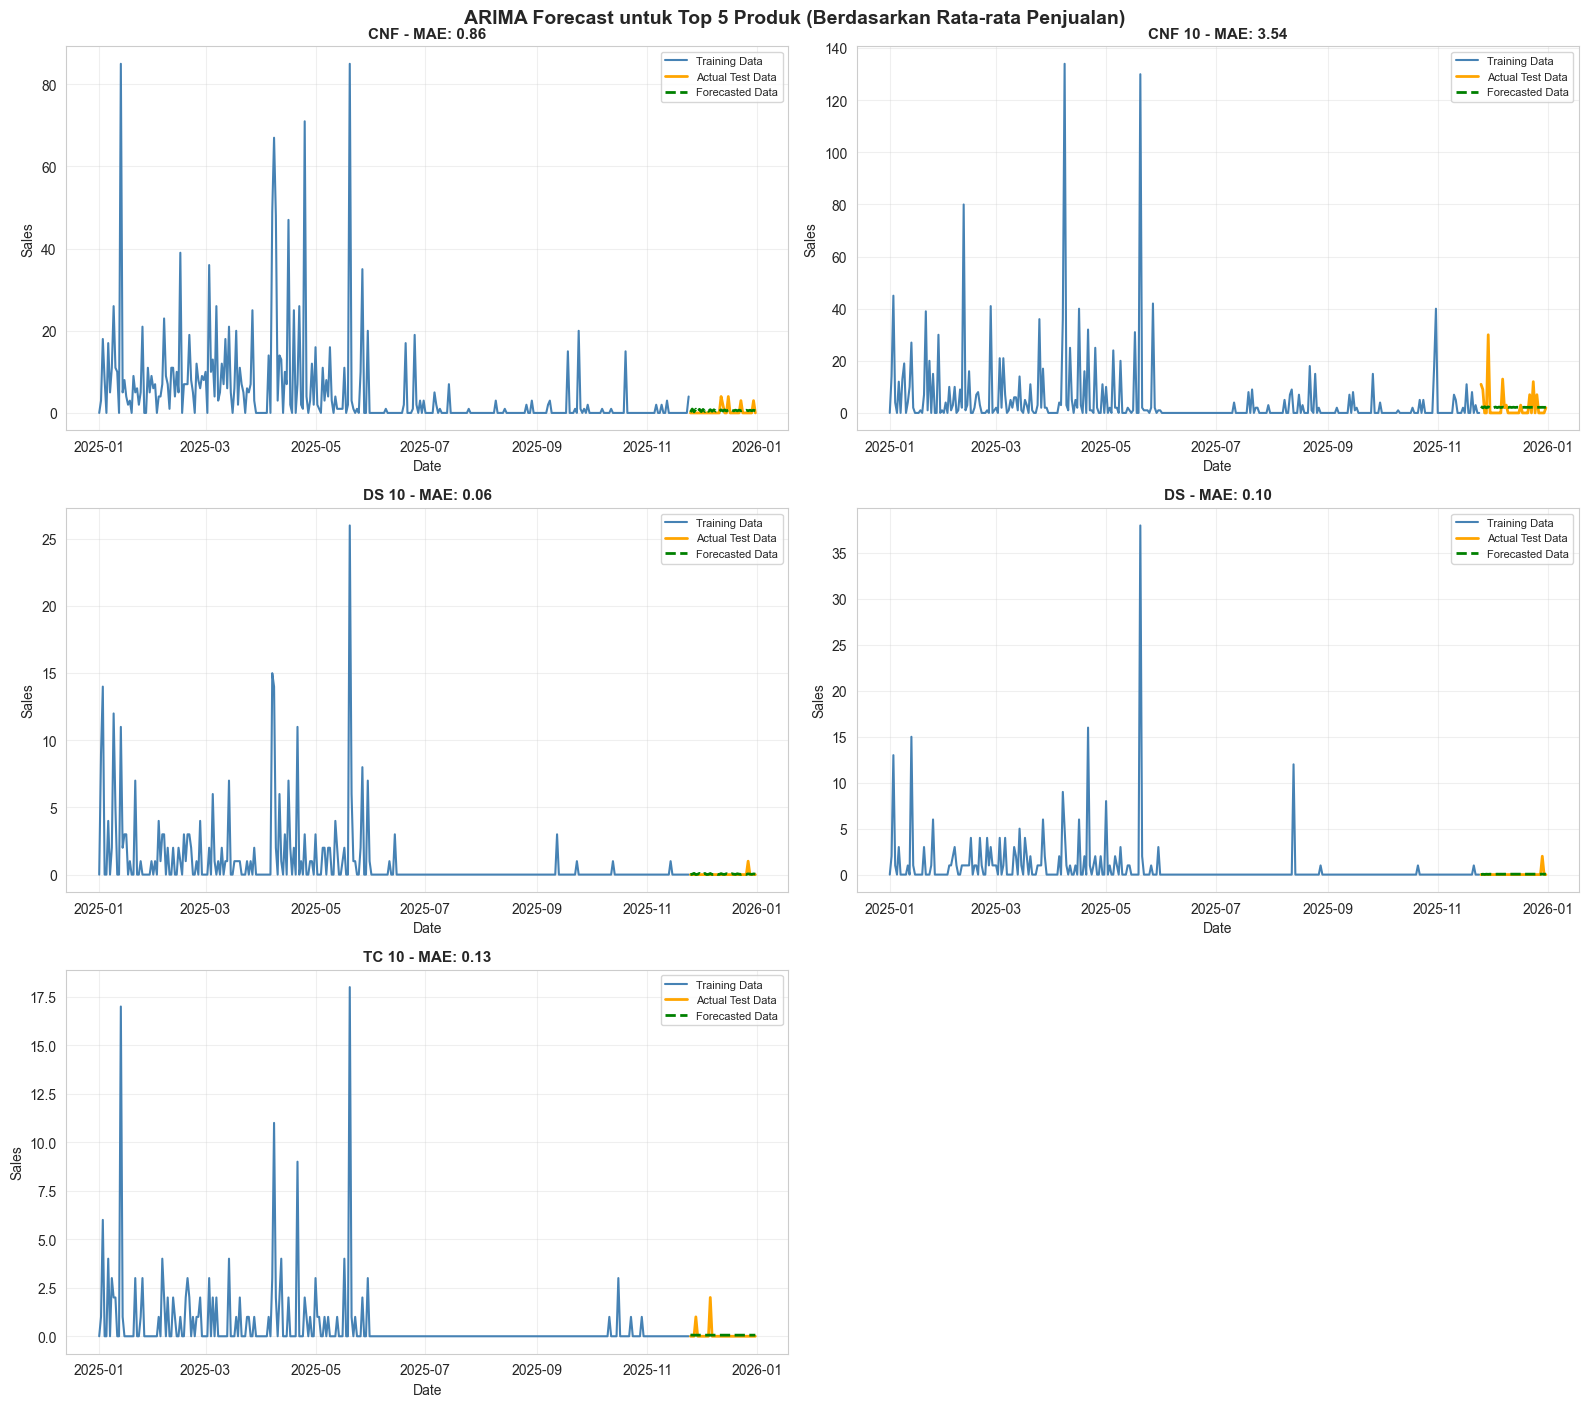

In [13]:

# Visualisasi forecast untuk 5 produk dengan penjualan tertinggi
# Hitung rata-rata penjualan per produk
avg_sales = dataset[product_columns].mean().sort_values(ascending=False)
top_5_products = avg_sales.head(5).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, product in enumerate(top_5_products):
    if product in forecast_results and forecast_results[product]['success']:
        result = forecast_results[product]
        
        ax = axes[idx]
        
        # Plot training data
        ax.plot(result['train_data'].index, result['train_data'], 
                label='Training Data', color='steelblue', linewidth=1.5)
        
        # Plot test data
        ax.plot(result['test_data'].index, result['test_data'], 
                label='Actual Test Data', color='orange', linewidth=2)
        
        # Plot forecast
        ax.plot(result['test_data'].index, result['forecast'], 
                label='Forecasted Data', linestyle='--', color='green', linewidth=2)
        
        ax.set_title(f'{product} - MAE: {result["mae"]:.2f}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Sales')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)

# Sembunyikan subplot ke-6 yang tidak terpakai
axes[5].set_visible(False)

plt.tight_layout()
plt.suptitle('ARIMA Forecast untuk Top 5 Produk (Berdasarkan Rata-rata Penjualan)', 
             fontsize=14, fontweight='bold', y=1.002)
plt.show()


## 9. Distribusi Error Metrics

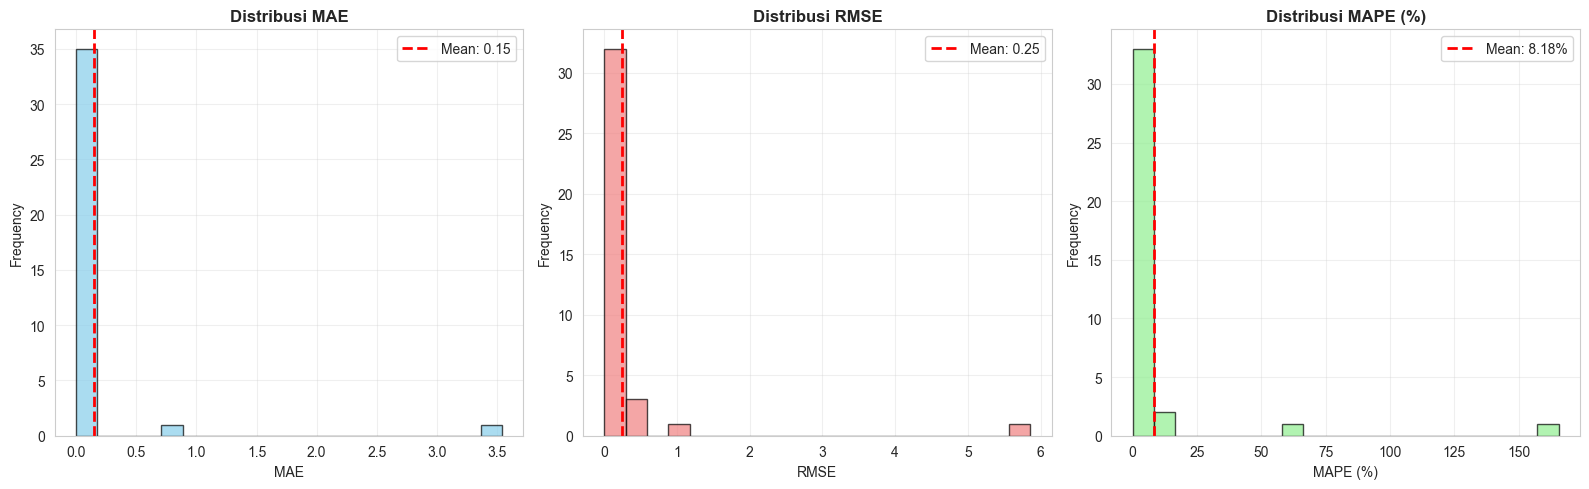

In [14]:
# Visualisasi distribusi error metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE Distribution
axes[0].hist(summary_df['MAE'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(summary_df['MAE'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {summary_df["MAE"].mean():.2f}')
axes[0].set_title('Distribusi MAE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('MAE')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE Distribution
axes[1].hist(summary_df['RMSE'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(summary_df['RMSE'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {summary_df["RMSE"].mean():.2f}')
axes[1].set_title('Distribusi RMSE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# MAPE Distribution
axes[2].hist(summary_df['MAPE (%)'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].axvline(summary_df['MAPE (%)'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {summary_df["MAPE (%)"].mean():.2f}%')
axes[2].set_title('Distribusi MAPE (%)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('MAPE (%)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Export Hasil Forecasting ke CSV

Export hasil forecasting dalam 2 format:
1. **Summary metrics** per produk
2. **Detailed forecast** dengan data aktual vs prediksi

In [15]:
# 1. Export Summary Metrics per Produk (sudah termasuk Kategori MAE)
summary_export = summary_df.copy()
summary_export = summary_export.sort_values('MAE', ascending=True)

output_file_1 = 'arima_forecast_summary_per_produk.csv'
summary_export.to_csv(output_file_1, index=False, encoding='utf-8-sig')

# 1b. Export tabel ringkas kategori MAE untuk integrasi Laravel
mae_category_summary = (
    summary_df.groupby('Kategori MAE', observed=True)
    .agg(
        jumlah_produk=('Produk', 'count'),
        mae_rata_rata=('MAE', 'mean'),
        rmse_rata_rata=('RMSE', 'mean'),
        mape_rata_rata=('MAPE (%)', 'mean')
    )
    .reset_index()
    .sort_values('Kategori MAE')
)

mae_category_summary['mae_rata_rata'] = mae_category_summary['mae_rata_rata'].round(2)
mae_category_summary['rmse_rata_rata'] = mae_category_summary['rmse_rata_rata'].round(2)
mae_category_summary['mape_rata_rata'] = mae_category_summary['mape_rata_rata'].round(2)

output_file_5 = 'arima_forecast_mae_kategori_ringkas.csv'
mae_category_summary.to_csv(output_file_5, index=False, encoding='utf-8-sig')

print(f"✅ Summary metrics berhasil disimpan ke: {output_file_1}")
print(f"✅ Ringkasan kategori MAE berhasil disimpan ke: {output_file_5}")
print(f"\nPreview (Top 10 produk dengan MAE terendah):")
print(summary_export.head(10).to_string(index=False))

print("\nPreview ringkasan kategori MAE:")
print(mae_category_summary.to_string(index=False))

✅ Summary metrics berhasil disimpan ke: arima_forecast_summary_per_produk.csv
✅ Ringkasan kategori MAE berhasil disimpan ke: arima_forecast_mae_kategori_ringkas.csv

Preview (Top 10 produk dengan MAE terendah):
 Produk ARIMA Order  MAE  RMSE  MAPE (%) Stationary  ADF p-value Kategori MAE
   BR45   (1, 1, 1)  0.0   0.0      0.00         Ya       0.0005       rendah
   BR75   (3, 1, 3)  0.0   0.0      0.30         Ya       0.0000       rendah
   EC75   (3, 1, 3)  0.0   0.0      0.30         Ya       0.0000       rendah
   EC45   (1, 1, 1)  0.0   0.0      0.00         Ya       0.0022       rendah
 DS 100   (2, 1, 2)  0.0   0.0      0.00      Tidak       0.1159       rendah
 DS 250   (1, 1, 1)  0.0   0.0      0.00         Ya       0.0000       rendah
CNF 250   (0, 1, 1)  0.0   0.0      0.23         Ya       0.0000       rendah
CNF 100   (1, 1, 1)  0.0   0.0      0.00         Ya       0.0010       rendah
JOY 100   (1, 1, 1)  0.0   0.0      0.01         Ya       0.0042       rendah
    LDR  

In [16]:
# 2. Export Detailed Forecast (Actual vs Predicted) untuk semua produk
detailed_forecast = []

# Mapping kategori MAE per produk agar siap dipakai di Laravel
product_mae_category_map = dict(zip(summary_df['Produk'], summary_df['Kategori MAE'].astype(str)))

for product, result in forecast_results.items():
    if result['success']:
        product_category = product_mae_category_map.get(product, 'unknown')
        for date, actual, predicted in zip(result['test_data'].index, 
                                           result['test_data'].values, 
                                           result['forecast'].values):
            detailed_forecast.append({
                'Date': date,
                'Produk': product,
                'Kategori_MAE': product_category,
                'Actual_Sales': round(actual, 2),
                'Predicted_Sales': round(predicted, 2),
                'Error': round(actual - predicted, 2),
                'Absolute_Error': round(abs(actual - predicted), 2)
            })

detailed_df = pd.DataFrame(detailed_forecast)

output_file_2 = 'arima_forecast_detailed_per_produk.csv'
detailed_df.to_csv(output_file_2, index=False, encoding='utf-8-sig')

print(f"\n✅ Detailed forecast berhasil disimpan ke: {output_file_2}")
print(f"\nTotal records: {len(detailed_df)}")
print(f"\nPreview 10 baris pertama:")
print(detailed_df.head(10).to_string(index=False))


✅ Detailed forecast berhasil disimpan ke: arima_forecast_detailed_per_produk.csv

Total records: 1369

Preview 10 baris pertama:
      Date  Produk Kategori_MAE  Actual_Sales  Predicted_Sales  Error  Absolute_Error
2025-11-25 AERIS10     menengah           0.0             0.01  -0.01            0.01
2025-11-26 AERIS10     menengah           0.0             0.01  -0.01            0.01
2025-11-27 AERIS10     menengah           0.0             0.01  -0.01            0.01
2025-11-28 AERIS10     menengah           0.0             0.01  -0.01            0.01
2025-11-29 AERIS10     menengah           0.0             0.01  -0.01            0.01
2025-11-30 AERIS10     menengah           0.0             0.01  -0.01            0.01
2025-12-01 AERIS10     menengah           0.0             0.01  -0.01            0.01
2025-12-02 AERIS10     menengah           0.0             0.01  -0.01            0.01
2025-12-03 AERIS10     menengah           0.0             0.01  -0.01            0.01
2025-12-04

## 11. Perbandingan Forecast dengan Aktual (Pivot Table)

In [17]:
# Buat pivot table untuk perbandingan actual vs predicted
pivot_actual = detailed_df.pivot_table(
    index='Date', 
    columns='Produk', 
    values='Actual_Sales'
)

pivot_predicted = detailed_df.pivot_table(
    index='Date', 
    columns='Produk', 
    values='Predicted_Sales'
)

# Export pivot tables
output_file_3 = 'arima_forecast_actual_pivot.csv'
output_file_4 = 'arima_forecast_predicted_pivot.csv'

pivot_actual.to_csv(output_file_3, encoding='utf-8-sig')
pivot_predicted.to_csv(output_file_4, encoding='utf-8-sig')

print(f"✅ Pivot table (Actual) disimpan ke: {output_file_3}")
print(f"✅ Pivot table (Predicted) disimpan ke: {output_file_4}")

print(f"\nPreview Actual Sales (5 produk pertama, 5 tanggal pertama):")
print(pivot_actual.iloc[:5, :5])

print(f"\nPreview Predicted Sales (5 produk pertama, 5 tanggal pertama):")
print(pivot_predicted.iloc[:5, :5])

✅ Pivot table (Actual) disimpan ke: arima_forecast_actual_pivot.csv
✅ Pivot table (Predicted) disimpan ke: arima_forecast_predicted_pivot.csv

Preview Actual Sales (5 produk pertama, 5 tanggal pertama):
Produk      AERIS10  BB 10  BB 30  BR45  BR75
Date                                         
2025-11-25      0.0    0.0    0.0   0.0   0.0
2025-11-26      0.0    0.0    0.0   0.0   0.0
2025-11-27      0.0    0.0    0.0   0.0   0.0
2025-11-28      0.0    0.0    0.0   0.0   0.0
2025-11-29      0.0    0.0    0.0   0.0   0.0

Preview Predicted Sales (5 produk pertama, 5 tanggal pertama):
Produk      AERIS10  BB 10  BB 30  BR45  BR75
Date                                         
2025-11-25     0.01   0.12   0.04   0.0   0.0
2025-11-26     0.01   0.11   0.04   0.0   0.0
2025-11-27     0.01   0.11   0.04   0.0   0.0
2025-11-28     0.01   0.10   0.04   0.0   0.0
2025-11-29     0.01   0.11   0.04   0.0   0.0


## 12. Kesimpulan dan Rekomendasi

In [18]:
print("\n" + "=" * 90)
print("KESIMPULAN DAN REKOMENDASI")
print("=" * 90)

# Hitung berapa produk yang berhasil di-forecast
successful_forecasts = sum(1 for r in forecast_results.values() if r['success'])

print(f"\n📊 HASIL FORECASTING:")
print(f"   • Total produk dianalisis: {len(product_columns)}")
print(f"   • Produk berhasil di-forecast: {successful_forecasts}")
print(f"   • Average MAE: {summary_df['MAE'].mean():.2f}")
print(f"   • Average RMSE: {summary_df['RMSE'].mean():.2f}")
print(f"   • Average MAPE: {summary_df['MAPE (%)'].mean():.2f}%")

if not summary_df.empty and 'Kategori MAE' in summary_df.columns:
    print("\n📌 DISTRIBUSI KATEGORI MAE:")
    cat_count = summary_df['Kategori MAE'].value_counts().sort_index()
    for cat_name, cat_total in cat_count.items():
        print(f"   • {cat_name}: {cat_total} produk")

print(f"\n🏆 PRODUK DENGAN PREDIKSI TERBAIK (Top 5):")
for idx, row in summary_df.nsmallest(5, 'MAE').iterrows():
    print(f"   {idx+1}. {row['Produk']}: MAE = {row['MAE']:.2f} | Order = {row['ARIMA Order']}")

print(f"\n⚠️  PRODUK YANG PERLU TUNING MODEL (Top 5):")
for idx, row in summary_df.nlargest(5, 'MAE').iterrows():
    print(f"   {idx+1}. {row['Produk']}: MAE = {row['MAE']:.2f} | Order = {row['ARIMA Order']}")

# Ringkasan distribusi order terpilih
order_distribution = summary_df['ARIMA Order'].value_counts().head(5)
print(f"\n🔎 ORDER ARIMA YANG PALING SERING TERPILIH (Top 5):")
for order_name, count in order_distribution.items():
    print(f"   • {order_name}: {count} produk")

print(f"\n💡 REKOMENDASI:")
print("   1. Produk dengan MAE rendah gunakan model paling sederhana yang performanya tetap baik (parsimonious)")
print("   2. Produk dengan MAE menengah/tinggi lakukan retuning dengan kandidat ARIMA yang lebih luas")
print("   3. Prioritaskan monitoring untuk produk dengan MAE tertinggi")
print("   4. Pertimbangkan SARIMA/fitur eksternal bila pola musiman atau lonjakan sulit ditangkap")

print("=" * 90)

# Export file list
print(f"\n📁 FILE YANG DIHASILKAN:")
print(f"   1. {output_file_1} - Summary metrics per produk")
print(f"   2. {output_file_2} - Detail forecast actual vs predicted")
print(f"   3. {output_file_3} - Pivot table actual sales")
print(f"   4. {output_file_4} - Pivot table predicted sales")
print(f"   5. {output_file_5} - Ringkasan kategori MAE (rendah/menengah/tinggi)")
print("=" * 90)


KESIMPULAN DAN REKOMENDASI

📊 HASIL FORECASTING:
   • Total produk dianalisis: 37
   • Produk berhasil di-forecast: 37
   • Average MAE: 0.15
   • Average RMSE: 0.25
   • Average MAPE: 8.18%

📌 DISTRIBUSI KATEGORI MAE:
   • rendah: 16 produk
   • menengah: 8 produk
   • tinggi: 13 produk

🏆 PRODUK DENGAN PREDIKSI TERBAIK (Top 5):
   4. BR45: MAE = 0.00 | Order = (1, 1, 1)
   5. BR75: MAE = 0.00 | Order = (3, 1, 3)
   9. CNF 100: MAE = 0.00 | Order = (1, 1, 1)
   10. CNF 250: MAE = 0.00 | Order = (0, 1, 1)
   13. DS 100: MAE = 0.00 | Order = (2, 1, 2)

⚠️  PRODUK YANG PERLU TUNING MODEL (Top 5):
   8. CNF 10: MAE = 3.54 | Order = (3, 1, 2)
   7. CNF: MAE = 0.86 | Order = (3, 1, 2)
   2. BB 10: MAE = 0.13 | Order = (3, 1, 3)
   34. TC 10: MAE = 0.13 | Order = (3, 1, 2)
   11. DS: MAE = 0.10 | Order = (2, 1, 3)

🔎 ORDER ARIMA YANG PALING SERING TERPILIH (Top 5):
   • (1, 1, 1): 10 produk
   • (3, 1, 2): 8 produk
   • (0, 1, 1): 8 produk
   • (3, 1, 3): 5 produk
   • (2, 1, 3): 4 produk

